In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns
import pandas as pd
import numpy as np

import scipy.stats
from scipy.stats import ttest_ind

import scienceplots
import warnings


import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

In [3]:
measure_col = 'half-life'
group_cols = ['Condition', 'Exp']

In [4]:
def remove_outliers_tukey(df, measure_col, group_cols, k=1.5):
    def tukey_fence(group):
        q1 = group[measure_col].quantile(0.25)
        q3 = group[measure_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        return group[(group[measure_col] >= lower) & (group[measure_col] <= upper)]
    
    return df.groupby(group_cols, group_keys=False).apply(tukey_fence)

In [5]:
# Superplots!!
def superplot(data, group_cols, measure_col, ttest=False, **kwargs):
    group_condition, group_replicate = group_cols

    # Ensure 'Control' is first and other conditions follow
    all_conditions = sorted([c for c in data[group_condition].unique() if c != 'Control'])
    ordered_conditions = ['Control'] + all_conditions
    data[group_condition] = pd.Categorical(data[group_condition], categories=ordered_conditions, ordered=True)

    # Calculate the average for each replicate within each condition
    replicate_averages = data.groupby(group_cols, as_index=False).agg({measure_col: 'mean'})

    # Compute mean and SEM across replicates
    condition_stats = replicate_averages.groupby(group_condition).agg(
        mean_measure=(measure_col, 'mean'),
        sem_measure=(measure_col, lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
    ).reset_index()

    # Create plot
    with plt.style.context('science'):
        plt.figure(figsize=(8, 6))

        # Raw data swarm plot
        sns.swarmplot(
            x=group_condition, y=measure_col, hue=group_replicate,
            data=data, size=5, edgecolor="k", linewidth=1.5, alpha=0.4, legend=False
        )

        # Replicate means
        sns.swarmplot(
            x=group_condition, y=measure_col, hue=group_replicate,
            data=replicate_averages, size=15, edgecolor="k", linewidth=2, dodge=True, alpha=0.6, legend=False
        )

        # Overlay mean and SEM whiskers for each condition and capture first for legend
        for i, row in condition_stats.iterrows():
            if i == 0:
                got_error = plt.errorbar(
                    x=i,
                    y=row['mean_measure'],
                    yerr=row['sem_measure'],
                    fmt='_',
                    color='black',
                    capsize=5,
                    elinewidth=2,
                    markersize=30
                )
            else:
                plt.errorbar(
                    x=i,
                    y=row['mean_measure'],
                    yerr=row['sem_measure'],
                    fmt='_',
                    color='black',
                    capsize=5,
                    elinewidth=2,
                    markersize=30
                )
        _, caplines, barlinecols = got_error
        custom_sem_handle = barlinecols[0]

        # p-values
        
        if ttest==True:
            try:
                control_vals = replicate_averages[replicate_averages[group_condition] == 'Control'][measure_col].values
                y_max = data[measure_col].max() + 2
                for i, cond in enumerate(all_conditions, start=1):
                    treatment_vals = replicate_averages[replicate_averages[group_condition] == cond][measure_col].values
                    stat, pval = ttest_ind(treatment_vals, control_vals, equal_var=False)
                    annotation = f"p = {pval:.4f}"
                    plt.text(i, y_max, annotation, ha='center', va='bottom', color='black')
            except Exception as e:
                warnings.warn(f"Could not compute test annotations: {e}")

        # Dots format
        custom_dot = Line2D([], [], marker='o', color='w', markerfacecolor='gray',
                            markeredgecolor='k', markersize=15, linewidth=2, alpha=0.6)

        # Legends format
        plt.legend(
            [custom_dot, got_error],
            [
                '\u00A0\u00A0\u00A0Mean of replicate N \nfor condition M',
                f'{measure_col.replace("_", " ").capitalize()} (mean ± SEM)\nacross replicates for condition M'
            ],
            loc='upper left',
            bbox_to_anchor=(0.02, 0.98),
            frameon=True,
            title=""
        )

        if 'xticks_fontsize' in list(kwargs.keys()):
            plt.xticks(fontsize=kwargs.get('xticks_fontsize'))
        else:
            plt.xticks(fontsize=14)
        if 'yticks_fontsize' in list(kwargs.keys()):
            plt.yticks(fontsize=kwargs.get('yticks_fontsize'))
        else:
            plt.yticks(fontsize=14)
        if ('xlabel' and 'xlabel_fontsize') in list(kwargs.keys()):
            plt.xlabel(kwargs.get('xlabel'), fontsize=kwargs.get('xlabel_fontsize'))
        if ('ylabel' and 'ylabel_fontsize') in list(kwargs.keys()):
            plt.ylabel(kwargs.get('ylabel'), fontsize=kwargs.get('ylabel_fontsize'))
        if ('title' and 'title_size') in list(kwargs.keys()):
            plt.title(kwargs.get('title'), fontsize=kwargs.get('title_size'))
        elif 'title' in list(kwargs.keys()):
            plt.title(kwargs['title'], fontsize=18)
        else:
            pass
        # Ticks
        plt.tick_params(axis='x', which='both', bottom=False, top=False)
        plt.tick_params(axis='y', which='both', left=True, right=True)

        # Grid
        plt.grid(False)
        plt.tight_layout()

        # Saving
        if ('save_path' in list(kwargs.keys()) and (kwargs.get('save_path') is not None)):
            plt.savefig(kwargs.get('save_path'))
        
        plt.show()


In [6]:
hl_df = pd.read_csv('decay_total', index_col=0)[['Condition','Exp','half-life']]

In [7]:
hl_cleaned = remove_outliers_tukey(hl_df, measure_col=measure_col, group_cols=group_cols, k=1.5)

C:\Users\pperez\AppData\Local\Temp\1\ipykernel_31932\977485057.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(tukey_fence)


C:\Users\pperez\AppData\Local\Temp\1\ipykernel_31932\3477841552.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  replicate_averages = data.groupby(group_cols, as_index=False).agg({measure_col: 'mean'})
C:\Users\pperez\AppData\Local\Temp\1\ipykernel_31932\3477841552.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_stats = replicate_averages.groupby(group_condition).agg(


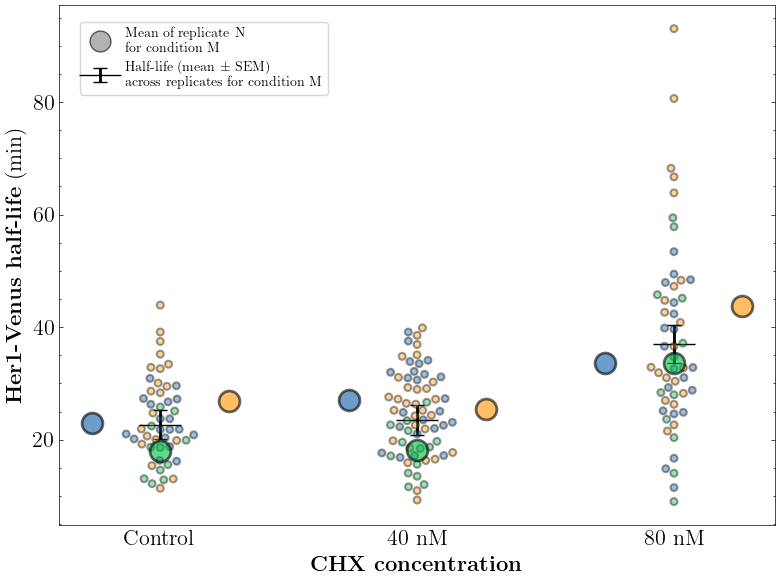

In [8]:
kwargs = {'title':None, 
          'title_fontsize':14, 
          'xlabel':r'\textbf{CHX concentration}',
          'xlabel_fontsize':16,
          'ylabel':r'\textbf{Her1-Venus half-life} (min)',
          'ylabel_fontsize':16,
          'xticks_fontsize':16,
          'yticks_fontsize':16,
          'save_path':None}
superplot(hl_cleaned, group_cols=['Condition','Exp'], measure_col=measure_col, **kwargs)